# Supervised Fine-Tuning (SFT) dengan LoRA

## Studi Kasus: Bahasa Daerah Indonesia

**Tujuan:** Fine-tune small language model agar dapat mengikuti instruksi dalam bahasa daerah Indonesia.

**Stack:**

- `transformers` — load model & tokenizer
- `peft` — LoRA implementation
- `trl` — SFTTrainer
- `datasets` — load & process data

> ⚠️ Tidak menggunakan Unsloth atau layanan as-a-service. Semua dibangun dari library standar HuggingFace.


## 0. Instalasi Dependencies


In [5]:
# Jalankan sekali saja di awal
# Di Colab: hapus tanda '#' di bawah
!uv pip install transformers==4.44.0 peft==0.12.0 trl==0.10.1 datasets accelerate bitsandbytes

Audited 6 packages in 12ms


## 1. Import dan Konfigurasi


In [6]:
import os
import json
import torch
from dataclasses import dataclass, field
from typing import List, Dict, Optional

from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    TrainingArguments,
)
from peft import LoraConfig, TaskType, get_peft_model, PeftModel
from trl import SFTTrainer, SFTConfig, DataCollatorForCompletionOnlyLM

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
    print(
        f"VRAM            : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB"
    )

/Users/juna/Project/MKA/PBAL/sft-lora-junaedifahmi/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


RuntimeError: Failed to import trl.trainer.sft_trainer because of the following error (look up to see its traceback):
No module named 'rich'

## 2. Konfigurasi Global

Ubah nilai di bawah sesuai pilihan Anda. Tidak perlu menyentuh kode lain.


In [7]:
# ============================================================
#   KONFIGURASI — ubah sesuai kebutuhan
# ============================================================

# --- Pilihan model (uncomment satu) ---
MODEL_ID = "HuggingFaceTB/SmolLM2-360M"  # ~360M param, sangat cepat
# MODEL_ID = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"  # ~1.1B param
# MODEL_ID = "Qwen/Qwen2.5-0.5B"                   # ~0.5B param, performa bagus
# MODEL_ID = "google/gemma-2-2b"                   # ~2B param, butuh akses HF
# MODEL_ID = "microsoft/Phi-3-mini-4k-instruct"    # ~3.8B param, pakai 4-bit

# --- Pilihan dataset ---
DATASET_CHOICE = "synthetic"  # 'synthetic' | 'nusax' | 'cendol' | 'bryandts'

# --- Direktori output ---
OUTPUT_DIR = "./output/sft-lora"
ADAPTER_DIR = "./output/adapter"
MERGED_DIR = "./output/merged-model"

# --- Hyperparameter pelatihan ---
MAX_SEQ_LEN = 512
NUM_EPOCHS = 2
BATCH_SIZE = 2  # turunkan ke 1 jika OOM
GRAD_ACCUM = 4  # efektif batch size = BATCH_SIZE * GRAD_ACCUM
LEARNING_RATE = 2e-4
MAX_TRAIN_SAMPLES = 1000  # None = pakai semua

# --- LoRA hyperparameter ---
LORA_R = 8
LORA_ALPHA = 16
LORA_DROPOUT = 0.05

# --- Kuantisasi (aktifkan untuk model >=2B di GPU < 8GB) ---
USE_4BIT = False

# Seed untuk reproducibility
SEED = 42
torch.manual_seed(SEED)

## 3. Bagian Eksplorasi: Mengapa Base Model Lemah dalam Mengikuti Instruksi?

> **Pertanyaan kunci:** Model yang dilatih pada triliunan token teks internet memiliki pengetahuan luas, tapi mengapa gagal menjawab instruksi sederhana?


In [8]:
# Muat tokenizer dan base model terlebih dahulu
print(f"Memuat model: {MODEL_ID}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)

# Pastikan tokenizer punya pad token
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

print(f"Vocabulary size : {tokenizer.vocab_size:,}")
print(f"EOS token       : {tokenizer.eos_token!r}")
print(f"PAD token       : {tokenizer.pad_token!r}")

Memuat model: HuggingFaceTB/SmolLM2-360M
Vocabulary size : 49,152
EOS token       : '<|endoftext|>'
PAD token       : '<|endoftext|>'


In [9]:
# Konfigurasi kuantisasi (opsional)
bnb_config = None
if USE_4BIT:
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.bfloat16,
    )

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto" if torch.cuda.is_available() else None,
    trust_remote_code=True,
)

total_params = sum(p.numel() for p in base_model.parameters())
print(f"Total parameter : {total_params:,} ({total_params / 1e6:.1f}M)")

Cancellation requested; stopping current tasks.


KeyboardInterrupt: 

In [ ]:
def generate_text(model, tokenizer, prompt: str, max_new_tokens: int = 200) -> str:
    """Helper: generate teks dari prompt."""
    model.eval()
    device = next(model.parameters()).device
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            repetition_penalty=1.1,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )
    # Hanya ambil bagian yang digenerate (bukan prompt)
    generated = outputs[0][inputs["input_ids"].shape[1] :]
    return tokenizer.decode(generated, skip_special_tokens=True)


# ============================================================
#   EKSPLORASI BASE MODEL — amati perilakunya sebelum fine-tuning
# ============================================================
test_prompts = [
    "Udin, sok urang tatarucingan yuk.",
    "Udin, urang tatarucingan yuk.",
    "Sahabat RAMA saatnya ",
]

print("=" * 60)
print("RESPONS BASE MODEL (sebelum fine-tuning)")
print("=" * 60)
for prompt in test_prompts:
    print(f"\n[INSTRUKSI]: {prompt}")
    response = generate_text(base_model, tokenizer, prompt)
    print(f"[RESPONS   ]: {response[:300]}")
    print("-" * 60)

print("""
ANALISIS:
Base model dilatih dengan objective 'next token prediction' pada teks mentah.
Ia belajar melanjutkan teks, BUKAN merespons instruksi.
Akibatnya: model cenderung melanjutkan kalimat tanya, bukan menjawabnya.
""")

RESPONS BASE MODEL (sebelum fine-tuning)

[INSTRUKSI]: Udin, sok urang tatarucingan yuk.
[RESPONS   ]: 

Karem, dunia punya sama yang mencoba kembali kepada itu, sejak mula ada banyak penggunaan itu di daerah kota Kepala Perdana Menteri. Mereka terus mencari jumlah nama yang berbeda-bedanya, dan paling perlukan menghabiskan nama yang sangat besar.

Rakyat ini mampu memperjuangkan negara kita. Sementa
------------------------------------------------------------

[INSTRUKSI]: Udin, urang tatarucingan yuk.
[RESPONS   ]: 

Tak tengok banyak tujuan di dalam buku kedua-dua berikut.

1. Saya mau mencari dua perkara yang sangat penting seperti:  tulis-tulis dan sistem teknologi.

Kita akan mempelajari komunikasi terhadap berbagai pembaca atau pengguna yang berada di dalam media digital dengan pemikiran ini (terdapat beb
------------------------------------------------------------

[INSTRUKSI]: Sahabat RAMA saatnya 
[RESPONS   ]: ia tahu bahwa segala-galanya yang menyebabkan kesakitan dan pemil

## 4. Persiapan Dataset

### Pilihan Dataset Bahasa Daerah Indonesia

| Dataset                  | HuggingFace ID                                                                    | Bahasa                                      | Format                        |
| ------------------------ | --------------------------------------------------------------------------------- | ------------------------------------------- | ----------------------------- |
| **Cendol Collection v2** | `indonlp/cendol_collection_v2`                                                    | 10+ regional (Jawa, Sunda, Batak, Bugis...) | instruction-output            |
| **Bryandts Instruct**    | `bryandts/instruction-dataset-indo-java-sunda-bali-gayo-batak-alas-minang-betawi` | 9 bahasa daerah                             | instruction-input-output      |
| **NusaX-MT**             | `indonlp/NusaX-MT`                                                                | 12 bahasa (ID + 10 regional)                | parallel translation          |
| **NusaX-Senti**          | `SEACrowd/nusax_senti`                                                            | 12 bahasa                                   | sentiment classification      |
| **Javanese Stories**     | `Iftitahu/javanese_instruct_stories`                                              | Jawa-Indonesia-Inggris                      | translation instruction       |
| **IndoNLG**              | `GEM/indonlg`                                                                     | ID, Jawa, Sunda                             | QA, summarization, MT, dialog |
| **Korpus Nusantara**     | `SEACrowd/korpus_nusantara`                                                       | 25 dialek                                   | parallel translation          |
| **Cendol v1**            | `indonlp/cendol_collection_v1`                                                    | 10+ regional                                | task-specific instruction     |

> **Rekomendasi:** Gunakan `bryandts/...` atau `indonlp/cendol_collection_v2` untuk SFT langsung karena sudah dalam format instruksi.


In [10]:
# ============================================================
#   DATASET SINTETIS BAHASA DAERAH (built-in, tanpa download)
#   Gunakan ini jika tidak ada koneksi internet
# ============================================================
with open("data/dataset.json") as f:
    SYNTHETIC_DATA = json.loads(f.read())

print(f"Dataset sintetis: {len(SYNTHETIC_DATA)} contoh")
print(f"Contoh pertama:")
print(f"  Instruksi : {SYNTHETIC_DATA[0]['instruction']}")
print(f"  Output    : {SYNTHETIC_DATA[0]['output'][:80]}...")

Dataset sintetis: 41 contoh
Contoh pertama:
  Instruksi : Jawab tatarucingan ieu: Awakna hideung, sirahna beureum, sukuna sarebu. Naon eta?
  Output    : Korek api (korek). Awakna (batang) hideung, sirahna beureum (bagian nu hurung), ...


In [11]:
def load_dataset_hf(choice: str, max_samples: Optional[int] = None) -> List[Dict]:
    """Muat dataset dari HuggingFace dan konversi ke format instruksi standar."""
    from datasets import load_dataset

    records = []

    if choice == "nusax":
        # NusaX-MT: terjemahan Indonesia <-> bahasa daerah
        # Format: Jadikan instruksi terjemahan
        ds = load_dataset(
            "indonlp/NusaX-MT", "ind-jav", split="train"
        )  # Indonesia-Jawa
        for row in ds:
            records.append(
                {
                    "instruction": f"Terjemahkan kalimat berikut dari bahasa Indonesia ke bahasa Jawa: {row['ind']}",
                    "input": "",
                    "output": row["jav"],
                }
            )

    elif choice == "cendol":
        # Cendol Collection v2: sudah dalam format instruksi
        ds = load_dataset("indonlp/cendol_collection_v2", split="train")
        for row in ds:
            records.append(
                {
                    "instruction": row.get("input", ""),
                    "input": "",
                    "output": row.get("output", ""),
                }
            )

    elif choice == "bryandts":
        # Bryandts: format Alpaca (instruction, input, output)
        ds = load_dataset(
            "bryandts/instruction-dataset-indo-java-sunda-bali-gayo-batak-alas-minang-betawi",
            split="train",
        )
        for row in ds:
            records.append(
                {
                    "instruction": row["instruction"],
                    "input": row.get("input", ""),
                    "output": row["output"],
                }
            )

    else:
        raise ValueError(f"Dataset tidak dikenal: {choice}")

    if max_samples:
        import random

        random.seed(SEED)
        records = random.sample(records, min(max_samples, len(records)))

    return records


# Pilih sumber data
if DATASET_CHOICE == "synthetic":
    raw_data = SYNTHETIC_DATA
    print(f"Menggunakan dataset sintetis: {len(raw_data)} contoh")
else:
    print(f"Memuat dataset dari HuggingFace: {DATASET_CHOICE}")
    raw_data = load_dataset_hf(DATASET_CHOICE, max_samples=MAX_TRAIN_SAMPLES)
    print(f"Jumlah data dimuat: {len(raw_data)}")

Menggunakan dataset sintetis: 41 contoh


In [12]:
# ============================================================
#   FORMAT KE CHAT TEMPLATE
#   Setiap contoh dikonversi ke format messages (role/content)
#   agar sesuai dengan chat template tokenizer
# ============================================================


def format_to_chat(record: Dict) -> Dict:
    """Konversi record {instruction, input, output} ke format chat messages."""
    user_content = record["instruction"]
    if record.get("input", "").strip():
        user_content = f"{user_content}\n\nKonteks:\n{record['input']}"

    return {
        "messages": [
            {"role": "user", "content": user_content},
            {"role": "assistant", "content": record["output"]},
        ]
    }


formatted = [format_to_chat(r) for r in raw_data]


# Terapkan chat template tokenizer
def apply_chat_template(examples):
    texts = []
    for msgs in examples["messages"]:
        try:
            text = tokenizer.apply_chat_template(
                msgs,
                tokenize=False,
                add_generation_prompt=False,
            )
        except Exception:
            # Fallback manual jika tokenizer tidak punya chat template
            user = msgs[0]["content"]
            asst = msgs[1]["content"]
            text = (
                f"### Instruksi:\n{user}\n\n### Respons:\n{asst}{tokenizer.eos_token}"
            )
        texts.append(text)
    return {"text": texts}


# Buat HuggingFace Dataset
hf_dataset = Dataset.from_list(formatted)
hf_dataset = hf_dataset.map(
    apply_chat_template, batched=True, remove_columns=["messages"]
)

# Train/val split 90/10
split = hf_dataset.train_test_split(test_size=0.1, seed=SEED)
train_dataset = split["train"]
eval_dataset = split["test"]

print(f"Train : {len(train_dataset)} contoh")
print(f"Eval  : {len(eval_dataset)} contoh")
print("\nContoh teks setelah format:")
print(train_dataset[0]["text"][:400])

Map: 100%|██████████| 41/41 [00:00<00:00, 17506.51 examples/s]

Train : 36 contoh
Eval  : 5 contoh

Contoh teks setelah format:
### Instruksi:
Jawab: Keur leutik nganggo baju, geus gédé buburak. Naon eta?

### Respons:
Buah rambutan atawa buah nu boga kulit. Waktu ngora masih aya dina kulitna (nganggo baju), geus asak/gédé buburak/dikupas.<|endoftext|>


## 5. Konfigurasi LoRA

LoRA menambahkan matriks berdimensi rendah $\Delta W = B \cdot A$ pada layer attention.
Hanya parameter $A$ dan $B$ yang dilatih, bukan bobot asli model.


In [13]:
# Target modules bervariasi per arsitektur model
TARGET_MODULES_MAP = {
    "SmolLM2": ["q_proj", "k_proj", "v_proj", "o_proj"],
    "TinyLlama": [
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],
    "Qwen2": [
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],
    "gemma": ["q_proj", "k_proj", "v_proj", "o_proj"],
    "Phi-3": ["qkv_proj", "o_proj", "gate_up_proj", "down_proj"],
}

# Deteksi arsitektur otomatis
arch = base_model.config.architectures[0] if base_model.config.architectures else ""
target_modules = ["q_proj", "v_proj"]  # default aman
for key, modules in TARGET_MODULES_MAP.items():
    if key.lower() in arch.lower() or key.lower() in MODEL_ID.lower():
        target_modules = modules
        break

print(f"Arsitektur   : {arch}")
print(f"Target modules: {target_modules}")

lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=target_modules,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)

# Terapkan LoRA pada model
model = get_peft_model(base_model, lora_config)

# Hitung parameter yang dapat dilatih
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"\nParameter dilatih : {trainable:,} ({100 * trainable / total:.2f}%)")
print(f"Parameter total   : {total:,}")
print(
    f"Parameter frozen  : {total - trainable:,} ({100 * (total - trainable) / total:.2f}%)"
)

NameError: name 'base_model' is not defined

## 6. Pelatihan dengan SFTTrainer


In [ ]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

sft_config = SFTConfig(
    # Output
    output_dir=OUTPUT_DIR,
    # Epoch & batch
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,
    # Memori
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
    # Presisi
    fp16=torch.cuda.is_available() and not USE_4BIT,
    bf16=False,
    # Optimizer
    optim="adamw_torch",
    learning_rate=LEARNING_RATE,
    weight_decay=0.01,
    warmup_ratio=0.05,
    lr_scheduler_type="cosine",
    # Sekuens
    max_seq_length=MAX_SEQ_LEN,
    dataset_text_field="text",
    packing=False,  # True untuk dataset kecil (efisiensi), False untuk dataset besar
    # Logging & Eval
    logging_steps=5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    # Reproducibility
    seed=SEED,
    report_to="none",
)

trainer = SFTTrainer(
    model=model,
    args=sft_config,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    tokenizer=tokenizer,
)

print("Konfigurasi pelatihan siap.")
print(f"  Efektif batch size : {BATCH_SIZE * GRAD_ACCUM}")
print(
    f"  Total steps        : {len(train_dataset) // (BATCH_SIZE * GRAD_ACCUM) * NUM_EPOCHS}"
)

Map:   0%|          | 0/4 [00:00<?, ? examples/s]

Map:   0%|          | 0/1 [00:00<?, ? examples/s]

Konfigurasi pelatihan siap.
  Efektif batch size : 8
  Total steps        : 0


In [ ]:
# ============================================================
#   MULAI PELATIHAN
# ============================================================
print("Memulai pelatihan...")
train_result = trainer.train()

print("\n--- Hasil Pelatihan ---")
print(f"Train loss akhir  : {train_result.training_loss:.4f}")
print(f"Total steps       : {train_result.global_step}")
print(f"Waktu pelatihan   : {train_result.metrics.get('train_runtime', 0):.1f} detik")

Memulai pelatihan...


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Epoch,Training Loss,Validation Loss
1,No log,5.630147
2,No log,5.608375


We detected that you are passing `past_key_values` as a tuple and this is deprecated and will be removed in v4.43. Please use an appropriate `Cache` class (https://huggingface.co/docs/transformers/v4.41.3/en/internal/generation_utils#transformers.Cache)



--- Hasil Pelatihan ---
Train loss akhir  : 2.8962
Total steps       : 2
Waktu pelatihan   : 10.3 detik


In [ ]:
# Simpan adapter LoRA (ringan — hanya bobot delta, bukan full model)
os.makedirs(ADAPTER_DIR, exist_ok=True)
model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)
print(f"Adapter LoRA disimpan di: {ADAPTER_DIR}")

# Tampilkan ukuran file
total_size = sum(
    os.path.getsize(os.path.join(ADAPTER_DIR, f))
    for f in os.listdir(ADAPTER_DIR)
    if os.path.isfile(os.path.join(ADAPTER_DIR, f))
)
print(f"Ukuran adapter    : {total_size / 1e6:.1f} MB")

Adapter LoRA disimpan di: ./output/adapter
Ukuran adapter    : 10.0 MB


## 7. Evaluasi Kualitatif

Bandingkan respons model **sebelum** dan **sesudah** fine-tuning pada prompt yang sama.


In [ ]:
# Muat ulang base model untuk perbandingan
base_model_eval = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto" if torch.cuda.is_available() else None,
    trust_remote_code=True,
)

# Muat model yang sudah di-fine-tune
finetuned_model = PeftModel.from_pretrained(base_model_eval, ADAPTER_DIR)
finetuned_model.eval()
print("Model fine-tuned berhasil dimuat.")

Model fine-tuned berhasil dimuat.


In [ ]:
# Prompt uji (di luar dataset pelatihan)
eval_prompts = [
    "Sahabat RAMA, saatnya",
    "Udin, urang tatarucingan yeuh.",
    "Udin, urang tatarucingan yeuh",
]

print("=" * 70)
print("PERBANDINGAN: BASE MODEL vs MODEL FINE-TUNED")
print("=" * 70)

for i, prompt in enumerate(eval_prompts, 1):
    print(f"\n{'=' * 70}")
    print(f"[Prompt {i}]: {prompt}")
    print("-" * 70)

    resp_base = generate_text(base_model_eval, tokenizer, prompt, max_new_tokens=150)
    print(f"[BASE MODEL]:\n{resp_base[:300]}")
    print()

    resp_ft = generate_text(finetuned_model, tokenizer, prompt, max_new_tokens=150)
    print(f"[FINE-TUNED]:\n{resp_ft[:300]}")

PERBANDINGAN: BASE MODEL vs MODEL FINE-TUNED

[Prompt 1]: Sahabat RAMA, saatnya
----------------------------------------------------------------------
[BASE MODEL]:
 kami baca kebangsaan dunia di Indonesia.
Ketika ini, membuat kesempatan untuk menyambut diri dan memberikan saluran perkiraan terhadap pelajaran dan pengalaman mereka.
Sebagai satu organisasi yang lebih baik, KSAHAMAT RAMA menjadi sebagian besar organisasi di Indonesia dan juga mampu menyampaikan s

[FINE-TUNED]:
 kali ini berkaitan dengan kecenderungan di Indonesia yang berbeda menjadi peristiwa kerja dan kehidupan orang-orang Islam.

"Pada 1985, rakyat Indonesia telah membantu segala komunitas dalam memperjuangkan apa-apa negara, bagaimana pembangunannya berlaku secara serta bersetuju lainnya," hanya berka

[Prompt 2]: Udin, urang tatarucingan yeuh.
----------------------------------------------------------------------
[BASE MODEL]:


“I do not want to know any more about you,” he said; “go and get your own home.”

He fo

## 8. Visualisasi Training Loss


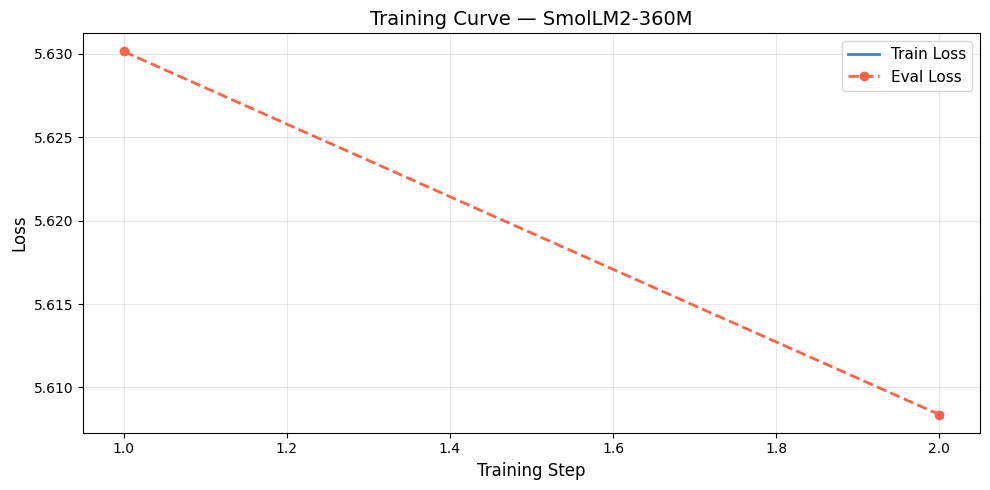

Grafik disimpan sebagai 'training_curve.png'


In [ ]:
import matplotlib.pyplot as plt

# Ambil log history dari trainer
log_history = trainer.state.log_history

train_steps = [x["step"] for x in log_history if "loss" in x]
train_losses = [x["loss"] for x in log_history if "loss" in x]
eval_steps = [x["step"] for x in log_history if "eval_loss" in x]
eval_losses = [x["eval_loss"] for x in log_history if "eval_loss" in x]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_steps, train_losses, label="Train Loss", color="steelblue", linewidth=2)
if eval_losses:
    ax.plot(
        eval_steps,
        eval_losses,
        label="Eval Loss",
        color="tomato",
        linestyle="--",
        marker="o",
        linewidth=2,
    )
ax.set_xlabel("Training Step", fontsize=12)
ax.set_ylabel("Loss", fontsize=12)
ax.set_title(f"Training Curve — {MODEL_ID.split('/')[-1]}", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("training_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grafik disimpan sebagai 'training_curve.png'")

## 9. (Opsional) Merge LoRA ke Base Model

Jika ingin menyimpan model lengkap (tanpa adapter terpisah) untuk deployment:


In [ ]:
# Merge adapter ke dalam bobot base model
# Catatan: membutuhkan RAM/VRAM lebih besar

MERGE_MODEL = False  # Ubah ke True jika ingin merge

if MERGE_MODEL:
    print("Merge adapter ke base model...")
    merged = finetuned_model.merge_and_unload()
    os.makedirs(MERGED_DIR, exist_ok=True)
    merged.save_pretrained(MERGED_DIR)
    tokenizer.save_pretrained(MERGED_DIR)
    print(f"Model merged disimpan di: {MERGED_DIR}")
else:
    print("Skip merge. Gunakan adapter terpisah saat inference.")
    print("Untuk load saat inference:")
    print("  base = AutoModelForCausalLM.from_pretrained(MODEL_ID)")
    print(f"  model = PeftModel.from_pretrained(base, '{ADAPTER_DIR}')")

Skip merge. Gunakan adapter terpisah saat inference.
Untuk load saat inference:
  base = AutoModelForCausalLM.from_pretrained(MODEL_ID)
  model = PeftModel.from_pretrained(base, './output/adapter')


## 10. Pertanyaan Analisis

Jawab pertanyaan berikut dalam laporan Anda:

1. **Berapa persen parameter yang dilatih dengan LoRA?** (lihat output sel 5)

2. **Mengapa base model gagal mengikuti instruksi?** Jelaskan dari sudut pandang fungsi loss saat pre-training.

3. **Bandingkan 3 contoh respons sebelum dan sesudah fine-tuning.** Apa perubahan yang Anda amati?

4. **Apakah ada tanda-tanda overfitting?** Bagaimana Anda mendeteksinya dari grafik loss?

5. **(Bonus)** Jika Anda membuat dataset bahasa daerah sendiri: apa tantangan terbesar dalam pembuatan data berkualitas?

---

_Selamat mengerjakan dan bereksperimen!_


## Jawaban Analisis

1. Parameter dilatih : 1,638,400 (0.45%)
2. Base model tidak dapat mengikuti instruksi, karena pada saat pelatihan base model, model hanya dilatih untuk melanjutkan teks, atau mengisi token yang hilang. Sedangkan intruksi adalah sebuah rangkaian token yang belum diketahui oleh model.
3. Kedua model yang dilatih dengan instruction, tidak memiliki perbedaan. Hal ini dikarenakan dataset yang diberikan tidak cukup untuk memberikan konteks.
4. Tidak dapat ditarik kesimpulan mengenai overfit, karena baik epoch maupun dataset masih belum cukup untuk belajar. Dan terlihat dari nilai loss yang ditampilkan, kemungkinan masih underfitting.
5. Membuat dataset sendiri perlu effort yang besar karena dataset yang kecil tidak dapat memberikan konteks yang cukup untuk melatih base model.
